# Unitary Synthesis Visualisations

This notebook provides visualisations for analysing the performance and characteristics of the Unitary Synthesiser.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import unitary_group
import time
from Unitary_Synthesis_V2 import UnitarySynthesiser
from decomposition_nodes import SingleQubitNode, AIIINode, TypeANode, IdentityNode

# Set style for nicer plots
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

## 1. Gate Count Distribution for a Single Unitary

Visualise the breakdown of gate types for a decomposed unitary.

Starting recursive KAK-decomposition, alternating AIII/A...
Decomposition complete.

Decomposition Summary:
  num_leaves: 8
  depth: 2
  gate_counts: {'SX': 16, 'Rz': 24, 'X': 0, 'CRY': 2, 'CRZ': 4}

Raw 2×2 Unitaries (before gate translation):
  Leaf 1 (SingleQubit):
    [+0.8137+0.0000j  -0.3712+0.4474j]
    [+0.3712+0.4474j  +0.8137+0.0000j]
  Leaf 2 (SingleQubit):
    [+0.2893-0.6572j  -0.6828+0.1346j]
    [+0.6021+0.3491j  +0.0602+0.7156j]
  Leaf 3 (SingleQubit):
    [+0.9953+0.0000j  +0.0671+0.0703j]
    [-0.0671+0.0703j  +0.9953+0.0000j]
  Leaf 4 (SingleQubit):
    [+0.3713+0.8658j  -0.3335+0.0351j]
    [-0.2858+0.1755j  +0.2336+0.9127j]


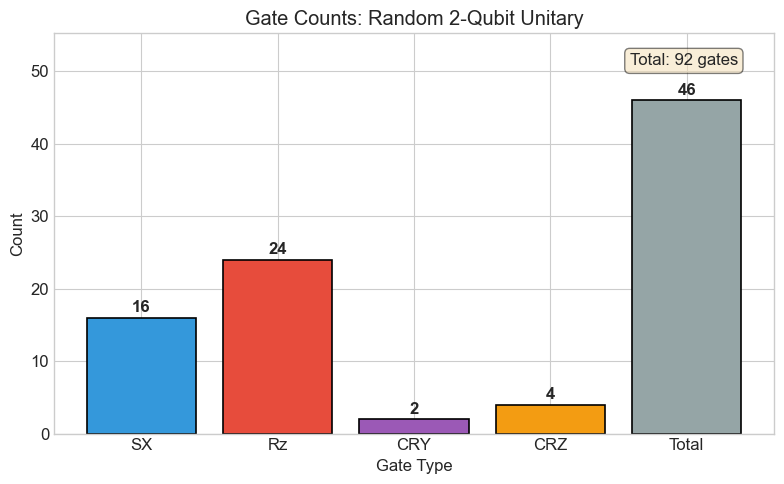

In [2]:
def plot_gate_counts(synth, title="Gate Count Distribution"):
    """Bar chart of gate counts from a synthesiser."""
    counts = synth.count_gates()
    
    # Filter out zero counts
    gates = [k for k, v in counts.items() if v > 0]
    values = [counts[k] for k in gates]
    
    colors = {'SX': '#3498db', 'Rz': '#e74c3c', 'X': '#2ecc71', 'CRY': '#9b59b6', 'CRZ': '#f39c12'}
    bar_colors = [colors.get(g, '#95a5a6') for g in gates]
    
    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.bar(gates, values, color=bar_colors, edgecolor='black', linewidth=1.2)
    
    # Add value labels on bars
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, 
                str(val), ha='center', va='bottom', fontweight='bold')
    
    ax.set_xlabel('Gate Type')
    ax.set_ylabel('Count')
    ax.set_title(title)
    ax.set_ylim(0, max(values) * 1.2 if values else 1)
    
    # Add total gate count
    total = sum(values)
    ax.text(0.95, 0.95, f'Total: {total} gates', transform=ax.transAxes, 
            ha='right', va='top', fontsize=12, 
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    return fig

# Example: Random 2-qubit unitary
U = unitary_group.rvs(4)
synth = UnitarySynthesiser(U)
synth.decompose()
synth.print_raw_unitaries()
plot_gate_counts(synth, "Gate Counts: Random 2-Qubit Unitary")
plt.show()

## 2. Comparing Different Unitaries

Compare gate counts across different types of unitaries (identity, Hadamard, CNOT, random).

In [3]:
def analyse_unitary(U, name):
    """Analyse a unitary and return metrics."""
    synth = UnitarySynthesiser(U)
    
    start = time.time()
    synth.decompose()
    elapsed = time.time() - start
    
    counts = synth.count_gates()
    total_gates = sum(counts.values())
    
    return {
        'name': name,
        'dimension': len(U),
        'total_gates': total_gates,
        'counts': counts,
        'depth': synth.get_depth(),
        'leaves': synth.count_leaves(),
        'time': elapsed
    }

# Define test unitaries
H = (1/np.sqrt(2)) * np.array([[1, 1], [1, -1]], dtype=complex)
I2 = np.eye(2, dtype=complex)
X = np.array([[0, 1], [1, 0]], dtype=complex)
CNOT = np.array([[1,0,0,0],[0,1,0,0],[0,0,0,1],[0,0,1,0]], dtype=complex)
random_2q = unitary_group.rvs(4)

# Analyse each
results = [
    analyse_unitary(I2, "Identity (1q)"),
    analyse_unitary(H, "Hadamard (1q)"),
    analyse_unitary(X, "X Gate (1q)"),
    analyse_unitary(CNOT, "CNOT (2q)"),
    analyse_unitary(random_2q, "Random (2q)"),
]

# Display results table
print(f"{'Unitary':<18} {'Dim':>5} {'Gates':>7} {'Depth':>7} {'Leaves':>7} {'Time (ms)':>10}")
print("-" * 60)
for r in results:
    print(f"{r['name']:<18} {r['dimension']:>5} {r['total_gates']:>7} {r['depth']:>7} {r['leaves']:>7} {r['time']*1000:>10.2f}")

Starting recursive KAK-decomposition, alternating AIII/A...
Decomposition complete.

Decomposition Summary:
  num_leaves: 1
  depth: 0
  gate_counts: {'SX': 0, 'Rz': 0, 'X': 0, 'CRY': 0, 'CRZ': 0}
Starting recursive KAK-decomposition, alternating AIII/A...
Decomposition complete.

Decomposition Summary:
  num_leaves: 1
  depth: 0
  gate_counts: {'SX': 2, 'Rz': 1, 'X': 0, 'CRY': 0, 'CRZ': 0}
Starting recursive KAK-decomposition, alternating AIII/A...
Decomposition complete.

Decomposition Summary:
  num_leaves: 1
  depth: 0
  gate_counts: {'SX': 0, 'Rz': 0, 'X': 1, 'CRY': 0, 'CRZ': 0}
Starting recursive KAK-decomposition, alternating AIII/A...
Decomposition complete.

Decomposition Summary:
  num_leaves: 8
  depth: 2
  gate_counts: {'SX': 8, 'Rz': 8, 'X': 0, 'CRY': 0, 'CRZ': 1}
Starting recursive KAK-decomposition, alternating AIII/A...
Decomposition complete.

Decomposition Summary:
  num_leaves: 8
  depth: 2
  gate_counts: {'SX': 16, 'Rz': 24, 'X': 0, 'CRY': 2, 'CRZ': 4}
Unitary      

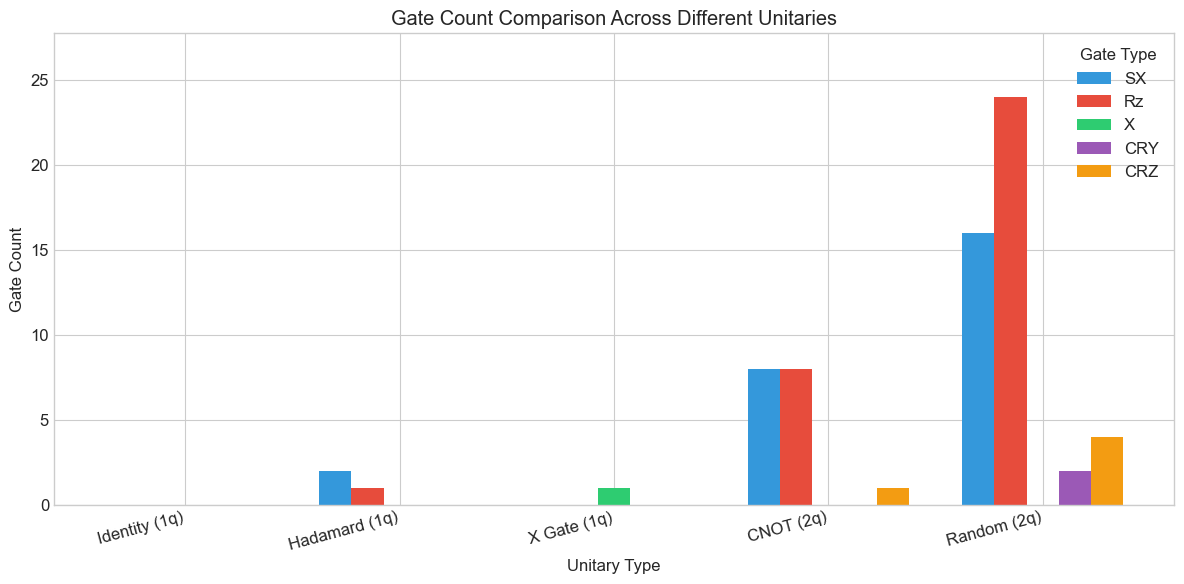

In [4]:
# Grouped bar chart comparison
fig, ax = plt.subplots(figsize=(12, 6))

names = [r['name'] for r in results]
gate_types = ['SX', 'Rz', 'X', 'CRY', 'CRZ']
x = np.arange(len(names))
width = 0.15

colors = {'SX': '#3498db', 'Rz': '#e74c3c', 'X': '#2ecc71', 'CRY': '#9b59b6', 'CRZ': '#f39c12'}

for i, gate in enumerate(gate_types):
    counts = [r['counts'].get(gate, 0) for r in results]
    if sum(counts) > 0:  # Only plot if there are any of this gate
        ax.bar(x + i * width, counts, width, label=gate, color=colors[gate])

ax.set_xlabel('Unitary Type')
ax.set_ylabel('Gate Count')
ax.set_title('Gate Count Comparison Across Different Unitaries')
ax.set_xticks(x + width * 2)
ax.set_xticklabels(names, rotation=15, ha='right')
ax.legend(title='Gate Type')
ax.set_ylim(0, ax.get_ylim()[1] * 1.1)

plt.tight_layout()
plt.show()

## 3. Scaling Analysis: Gate Count vs Number of Qubits

How does the gate count grow as we increase the number of qubits?

In [16]:
# Analyse scaling (this may take a few seconds for larger unitaries)
qubit_range = [1, 2, 3, 4, 5]  # 2^1=2, 2^2=4, 2^3=8 dimensions
num_samples = 5  # Average over multiple random unitaries

scaling_results = []

for n_qubits in qubit_range:
    dim = 2 ** n_qubits
    print(f"Analysing {n_qubits}-qubit unitaries ({dim}x{dim})...")
    
    sample_results = []
    for _ in range(num_samples):
        U = unitary_group.rvs(dim)
        result = analyse_unitary(U, f"{n_qubits}q")
        sample_results.append(result)
    
    # Average the metrics
    avg_gates = np.mean([r['total_gates'] for r in sample_results])
    std_gates = np.std([r['total_gates'] for r in sample_results])
    avg_time = np.mean([r['time'] for r in sample_results])
    avg_depth = np.mean([r['depth'] for r in sample_results])
    
    # Average gate type counts
    avg_counts = {}
    for gate in ['SX', 'Rz', 'X', 'CRY', 'CRZ']:
        avg_counts[gate] = np.mean([r['counts'].get(gate, 0) for r in sample_results])
    
    scaling_results.append({
        'n_qubits': n_qubits,
        'dimension': dim,
        'avg_gates': avg_gates,
        'std_gates': std_gates,
        'avg_time': avg_time,
        'avg_depth': avg_depth,
        'avg_counts': avg_counts
    })

print("\nScaling analysis complete!")

Analysing 1-qubit unitaries (2x2)...
Starting recursive KAK-decomposition, alternating AIII/A...
Decomposition complete.

Decomposition Summary:
  num_leaves: 1
  depth: 0
  gate_counts: {'SX': 2, 'Rz': 3, 'X': 0, 'CRY': 0, 'CRZ': 0}
Starting recursive KAK-decomposition, alternating AIII/A...
Decomposition complete.

Decomposition Summary:
  num_leaves: 1
  depth: 0
  gate_counts: {'SX': 2, 'Rz': 3, 'X': 0, 'CRY': 0, 'CRZ': 0}
Starting recursive KAK-decomposition, alternating AIII/A...
Decomposition complete.

Decomposition Summary:
  num_leaves: 1
  depth: 0
  gate_counts: {'SX': 2, 'Rz': 3, 'X': 0, 'CRY': 0, 'CRZ': 0}
Starting recursive KAK-decomposition, alternating AIII/A...
Decomposition complete.

Decomposition Summary:
  num_leaves: 1
  depth: 0
  gate_counts: {'SX': 2, 'Rz': 3, 'X': 0, 'CRY': 0, 'CRZ': 0}
Starting recursive KAK-decomposition, alternating AIII/A...
Decomposition complete.

Decomposition Summary:
  num_leaves: 1
  depth: 0
  gate_counts: {'SX': 2, 'Rz': 3, 'X': 0

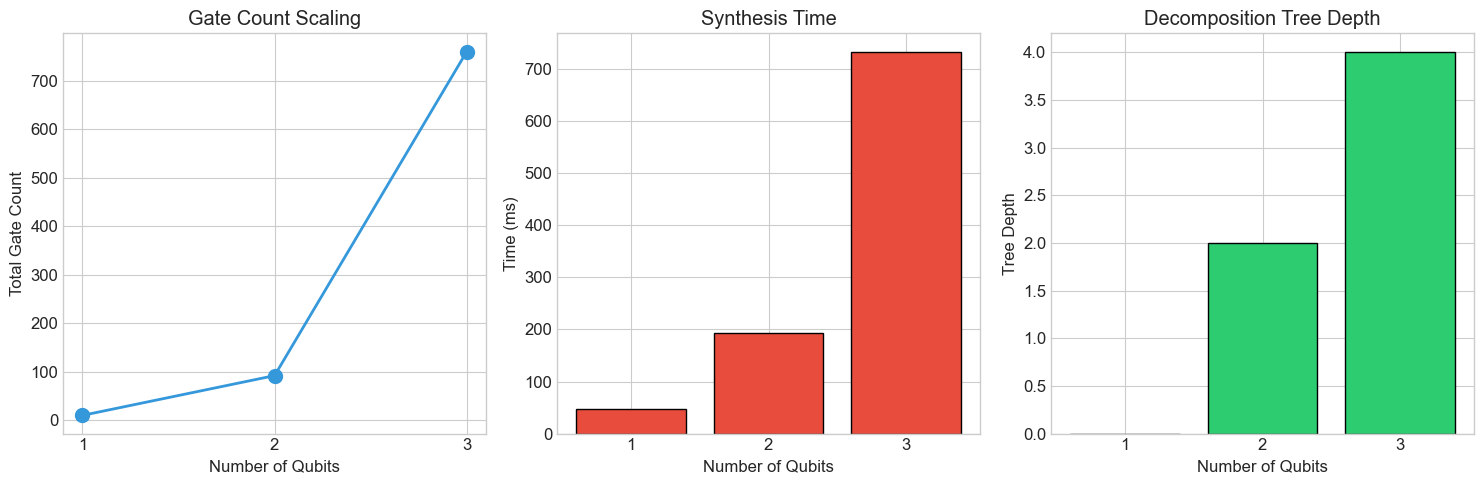

In [ ]:
# Plot scaling results
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

qubits = [r['n_qubits'] for r in scaling_results]

# Plot 1: Total gate count
ax1 = axes[0]
avg_gates = [r['avg_gates'] for r in scaling_results]
std_gates = [r['std_gates'] for r in scaling_results]
ax1.errorbar(qubits, avg_gates, yerr=std_gates, marker='o', capsize=5, 
             color='#3498db', linewidth=2, markersize=10)
ax1.set_xlabel('Number of Qubits')
ax1.scale('log')
ax1.set_ylabel('Total Gate Count')
ax1.set_title('Gate Count Scaling')
ax1.set_xticks(qubits)

# Plot 2: Synthesis time
ax2 = axes[1]
times = [r['avg_time'] * 1000 for r in scaling_results]  # Convert to ms
ax2.bar(qubits, times, color='#e74c3c', edgecolor='black')
ax2.set_xlabel('Number of Qubits')
ax2.set_ylabel('Time (ms)')
ax2.set_title('Synthesis Time')
ax2.set_xticks(qubits)

# Plot 3: Decomposition depth
ax3 = axes[2]
depths = [r['avg_depth'] for r in scaling_results]
ax3.bar(qubits, depths, color='#2ecc71', edgecolor='black')
ax3.set_xlabel('Number of Qubits')
ax3.set_ylabel('Tree Depth')
ax3.set_title('Decomposition Tree Depth')
ax3.set_xticks(qubits)

plt.tight_layout()
plt.show()

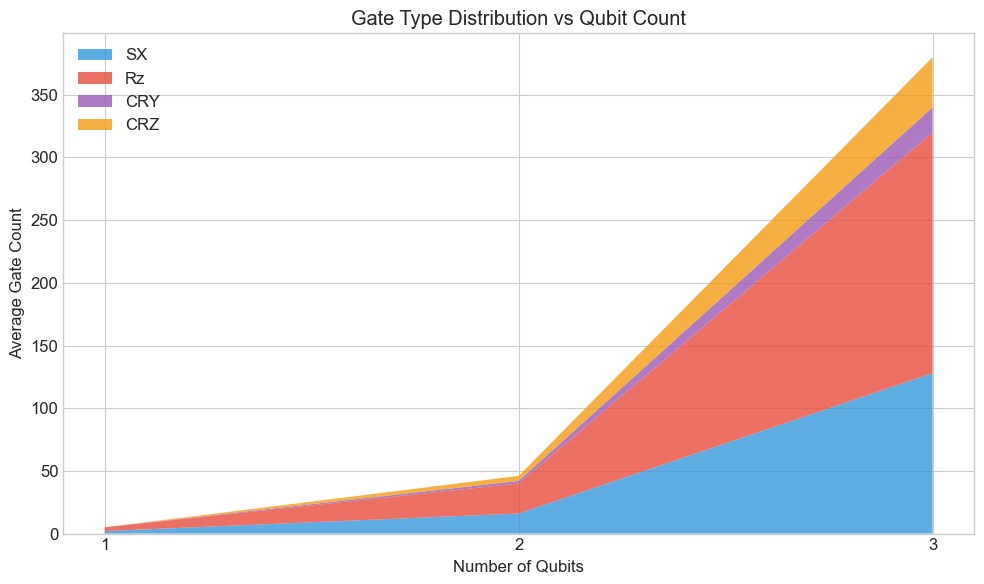

In [7]:
# Stacked area chart: gate types by qubit count
fig, ax = plt.subplots(figsize=(10, 6))

gate_types = ['SX', 'Rz', 'CRY', 'CRZ']
colors = ['#3498db', '#e74c3c', '#9b59b6', '#f39c12']

data = {gate: [r['avg_counts'].get(gate, 0) for r in scaling_results] for gate in gate_types}

ax.stackplot(qubits, *[data[g] for g in gate_types], labels=gate_types, colors=colors, alpha=0.8)
ax.set_xlabel('Number of Qubits')
ax.set_ylabel('Average Gate Count')
ax.set_title('Gate Type Distribution vs Qubit Count')
ax.legend(loc='upper left')
ax.set_xticks(qubits)

plt.tight_layout()
plt.show()

## 4. Gate Count Histogram for Random Unitaries

Distribution of gate counts across many random unitaries of the same size.

In [8]:
# Generate many random 2-qubit unitaries
n_samples = 50
dim = 4  # 2-qubit

print(f"Generating {n_samples} random 2-qubit unitaries...")

gate_totals = []
sx_counts = []
rz_counts = []
cry_counts = []

for i in range(n_samples):
    U = unitary_group.rvs(dim)
    synth = UnitarySynthesiser(U)
    synth.decompose()
    counts = synth.count_gates()
    
    gate_totals.append(sum(counts.values()))
    sx_counts.append(counts.get('SX', 0))
    rz_counts.append(counts.get('Rz', 0))
    cry_counts.append(counts.get('CRY', 0))

print(f"Mean total gates: {np.mean(gate_totals):.1f} ± {np.std(gate_totals):.1f}")

Generating 50 random 2-qubit unitaries...
Starting recursive KAK-decomposition, alternating AIII/A...
Decomposition complete.

Decomposition Summary:
  num_leaves: 8
  depth: 2
  gate_counts: {'SX': 16, 'Rz': 24, 'X': 0, 'CRY': 2, 'CRZ': 4}
Starting recursive KAK-decomposition, alternating AIII/A...
Decomposition complete.

Decomposition Summary:
  num_leaves: 8
  depth: 2
  gate_counts: {'SX': 16, 'Rz': 24, 'X': 0, 'CRY': 2, 'CRZ': 4}
Starting recursive KAK-decomposition, alternating AIII/A...
Decomposition complete.

Decomposition Summary:
  num_leaves: 8
  depth: 2
  gate_counts: {'SX': 16, 'Rz': 24, 'X': 0, 'CRY': 2, 'CRZ': 4}
Starting recursive KAK-decomposition, alternating AIII/A...
Decomposition complete.

Decomposition Summary:
  num_leaves: 8
  depth: 2
  gate_counts: {'SX': 16, 'Rz': 24, 'X': 0, 'CRY': 2, 'CRZ': 4}
Starting recursive KAK-decomposition, alternating AIII/A...
Decomposition complete.

Decomposition Summary:
  num_leaves: 8
  depth: 2
  gate_counts: {'SX': 16, '

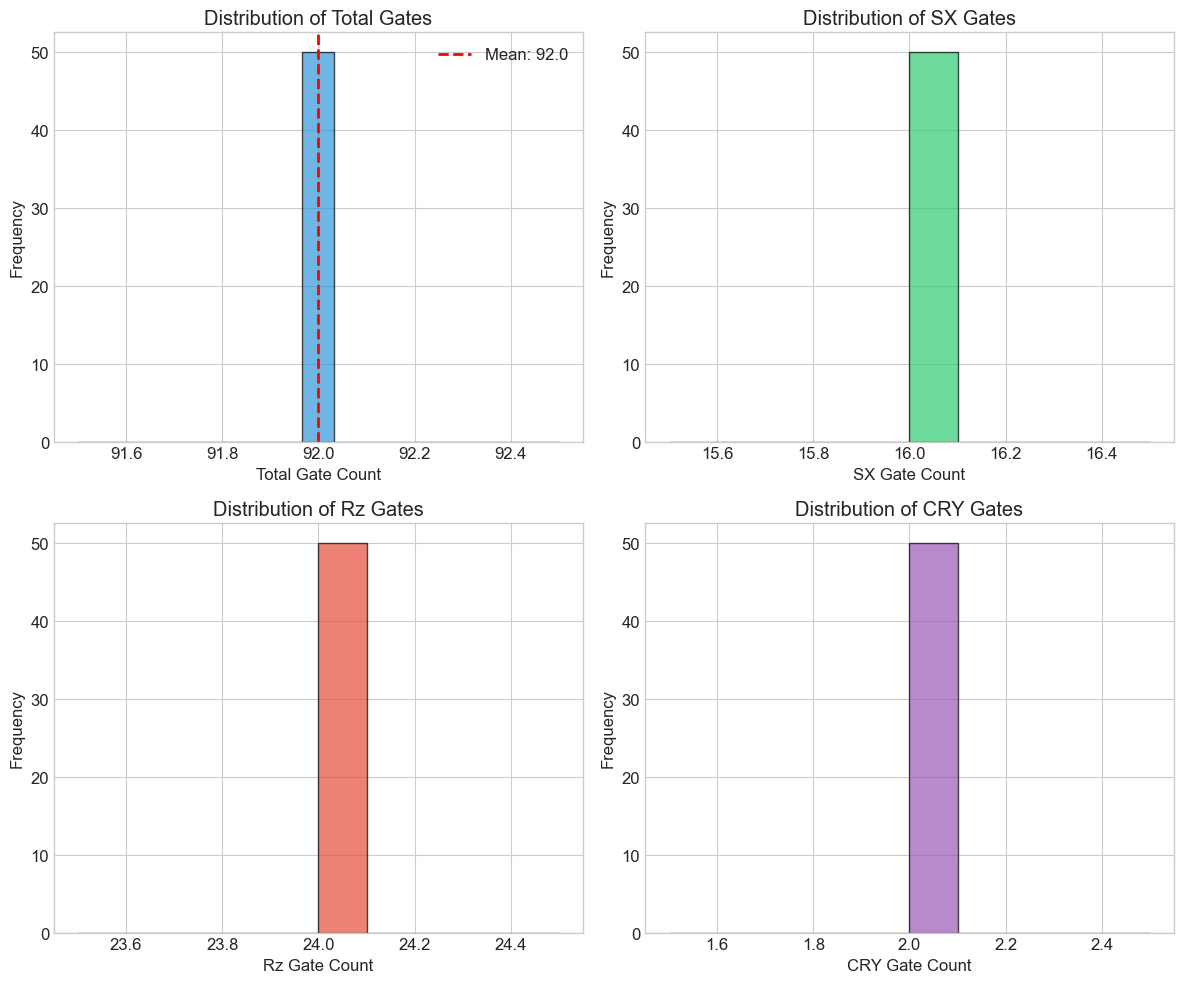

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Total gates histogram
axes[0, 0].hist(gate_totals, bins=15, color='#3498db', edgecolor='black', alpha=0.7)
axes[0, 0].axvline(np.mean(gate_totals), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(gate_totals):.1f}')
axes[0, 0].set_xlabel('Total Gate Count')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Total Gates')
axes[0, 0].legend()

# SX gates
axes[0, 1].hist(sx_counts, bins=10, color='#2ecc71', edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('SX Gate Count')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Distribution of SX Gates')

# Rz gates
axes[1, 0].hist(rz_counts, bins=10, color='#e74c3c', edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Rz Gate Count')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Distribution of Rz Gates')

# CRY gates
axes[1, 1].hist(cry_counts, bins=10, color='#9b59b6', edgecolor='black', alpha=0.7)
axes[1, 1].set_xlabel('CRY Gate Count')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Distribution of CRY Gates')

plt.tight_layout()
plt.show()

## 5. Pie Chart: Gate Type Proportions

Starting recursive KAK-decomposition, alternating AIII/A...
Decomposition complete.

Decomposition Summary:
  num_leaves: 8
  depth: 2
  gate_counts: {'SX': 16, 'Rz': 24, 'X': 0, 'CRY': 2, 'CRZ': 4}


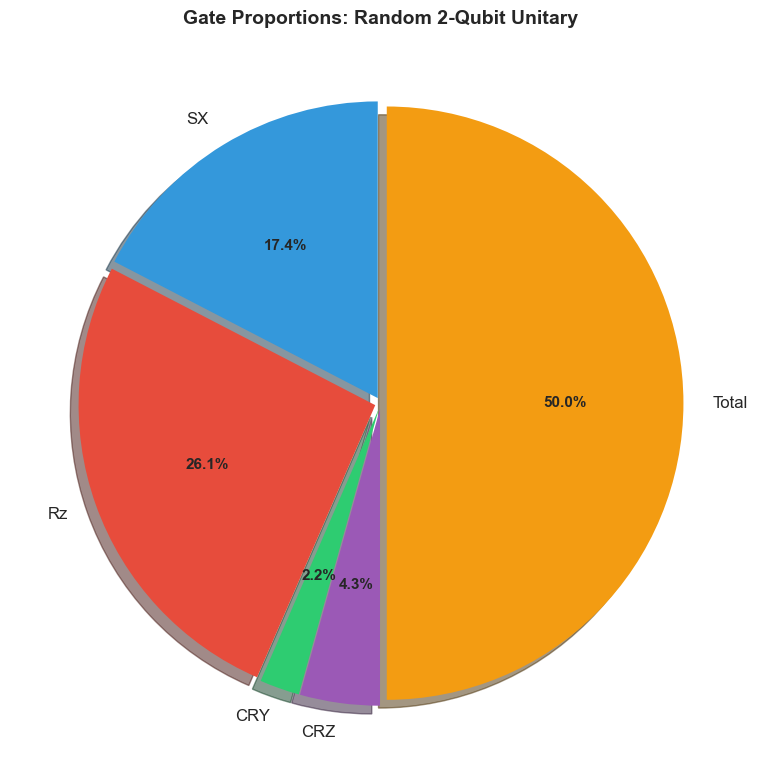

In [10]:
def plot_gate_pie(synth, title="Gate Type Proportions"):
    """Pie chart of gate proportions."""
    counts = synth.count_gates()
    
    # Filter non-zero
    gates = [k for k, v in counts.items() if v > 0]
    values = [counts[k] for k in gates]
    
    if not values:
        print("No gates to display (identity?)")
        return
    
    colors = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6', '#f39c12']
    
    fig, ax = plt.subplots(figsize=(8, 8))
    wedges, texts, autotexts = ax.pie(values, labels=gates, autopct='%1.1f%%', 
                                       colors=colors[:len(gates)], explode=[0.02]*len(gates),
                                       shadow=True, startangle=90)
    ax.set_title(title, fontsize=14, fontweight='bold')
    
    # Style the percentage text
    for autotext in autotexts:
        autotext.set_fontsize(11)
        autotext.set_fontweight('bold')
    
    plt.tight_layout()
    return fig

# Example with a random unitary
U = unitary_group.rvs(4)
synth = UnitarySynthesiser(U)
synth.decompose()
plot_gate_pie(synth, "Gate Proportions: Random 2-Qubit Unitary")
plt.show()

## 6. Heatmap: Parameter Angles Analysis

Visualise the distribution of rotation angles used in decompositions.

In [11]:
def collect_angles(node, rz_angles=None, theta_angles=None, phi_angles=None):
    """Recursively collect all rotation angles from the decomposition tree."""
    if rz_angles is None:
        rz_angles, theta_angles, phi_angles = [], [], []
    
    if isinstance(node, SingleQubitNode):
        for gate, angle in node.gates:
            if gate == 'Rz' and angle is not None:
                rz_angles.append(angle)
    elif isinstance(node, AIIINode):
        theta_angles.extend(node.theta)
        collect_angles(node.k1, rz_angles, theta_angles, phi_angles)
        collect_angles(node.k2, rz_angles, theta_angles, phi_angles)
    elif isinstance(node, TypeANode):
        phi_angles.extend(node.phi)
        collect_angles(node.w, rz_angles, theta_angles, phi_angles)
        collect_angles(node.x, rz_angles, theta_angles, phi_angles)
    
    return rz_angles, theta_angles, phi_angles

# Collect angles from multiple random unitaries
all_rz, all_theta, all_phi = [], [], []

for _ in range(30):
    U = unitary_group.rvs(4)
    synth = UnitarySynthesiser(U)
    synth.decompose()
    rz, theta, phi = collect_angles(synth.decomposition_tree)
    all_rz.extend(rz)
    all_theta.extend(theta)
    all_phi.extend(phi)

print(f"Collected {len(all_rz)} Rz angles, {len(all_theta)} theta angles, {len(all_phi)} phi angles")

Starting recursive KAK-decomposition, alternating AIII/A...
Decomposition complete.

Decomposition Summary:
  num_leaves: 8
  depth: 2
  gate_counts: {'SX': 16, 'Rz': 24, 'X': 0, 'CRY': 2, 'CRZ': 4}
Starting recursive KAK-decomposition, alternating AIII/A...
Decomposition complete.

Decomposition Summary:
  num_leaves: 8
  depth: 2
  gate_counts: {'SX': 16, 'Rz': 24, 'X': 0, 'CRY': 2, 'CRZ': 4}
Starting recursive KAK-decomposition, alternating AIII/A...
Decomposition complete.

Decomposition Summary:
  num_leaves: 8
  depth: 2
  gate_counts: {'SX': 16, 'Rz': 24, 'X': 0, 'CRY': 2, 'CRZ': 4}
Starting recursive KAK-decomposition, alternating AIII/A...
Decomposition complete.

Decomposition Summary:
  num_leaves: 8
  depth: 2
  gate_counts: {'SX': 16, 'Rz': 24, 'X': 0, 'CRY': 2, 'CRZ': 4}
Starting recursive KAK-decomposition, alternating AIII/A...
Decomposition complete.

Decomposition Summary:
  num_leaves: 8
  depth: 2
  gate_counts: {'SX': 16, 'Rz': 24, 'X': 0, 'CRY': 2, 'CRZ': 4}
Start

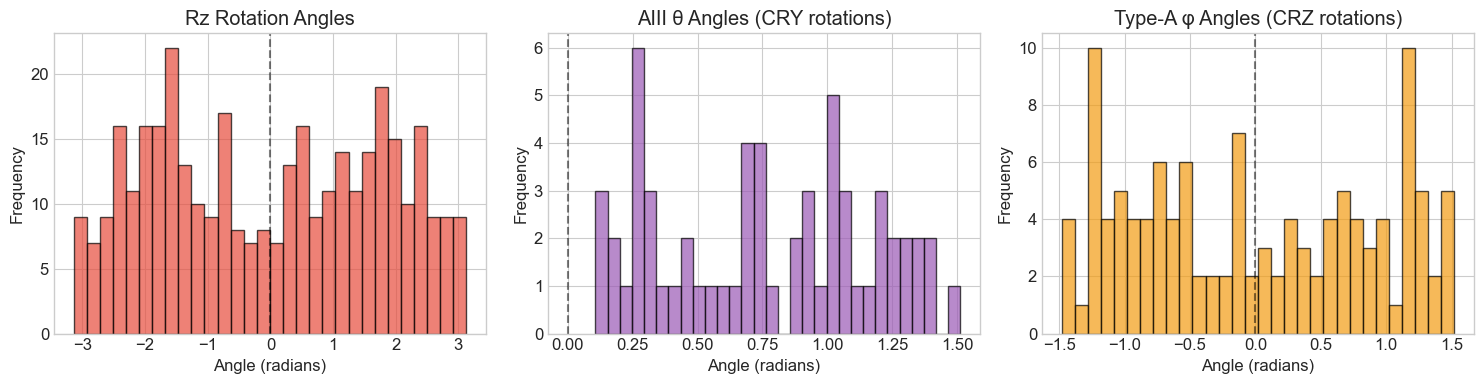

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Rz angles
if all_rz:
    axes[0].hist(all_rz, bins=30, color='#e74c3c', edgecolor='black', alpha=0.7)
    axes[0].set_xlabel('Angle (radians)')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title('Rz Rotation Angles')
    axes[0].axvline(0, color='black', linestyle='--', alpha=0.5)
else:
    axes[0].text(0.5, 0.5, 'No Rz angles', ha='center', va='center')

# Theta angles (CRY)
if all_theta:
    axes[1].hist(all_theta, bins=30, color='#9b59b6', edgecolor='black', alpha=0.7)
    axes[1].set_xlabel('Angle (radians)')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title('AIII θ Angles (CRY rotations)')
    axes[1].axvline(0, color='black', linestyle='--', alpha=0.5)
else:
    axes[1].text(0.5, 0.5, 'No theta angles', ha='center', va='center')

# Phi angles (CRZ)
if all_phi:
    axes[2].hist(all_phi, bins=30, color='#f39c12', edgecolor='black', alpha=0.7)
    axes[2].set_xlabel('Angle (radians)')
    axes[2].set_ylabel('Frequency')
    axes[2].set_title('Type-A φ Angles (CRZ rotations)')
    axes[2].axvline(0, color='black', linestyle='--', alpha=0.5)
else:
    axes[2].text(0.5, 0.5, 'No phi angles', ha='center', va='center')

plt.tight_layout()
plt.show()

## 7. Verification Error Analysis

How accurate is the decomposition? Plot reconstruction errors.

In [13]:
def compute_error(synth):
    """Compute reconstruction error (Frobenius norm)."""
    reconstructed = synth.decomposition_tree.reconstruct(synth.gates)
    
    # Try to match global phase
    product = synth.unitary @ reconstructed.conj().T
    phase = np.angle(product.flat[0])
    adjusted = reconstructed * np.exp(1j * phase)
    
    error = np.linalg.norm(synth.unitary - adjusted, 'fro')
    return error

# Compute errors for many random unitaries
errors = []
dims = []

for n_qubits in [1, 2, 3]:
    dim = 2 ** n_qubits
    for _ in range(20):
        U = unitary_group.rvs(dim)
        synth = UnitarySynthesiser(U)
        synth.decompose()
        err = compute_error(synth)
        errors.append(err)
        dims.append(n_qubits)

print(f"Max error: {max(errors):.2e}")
print(f"Mean error: {np.mean(errors):.2e}")

Starting recursive KAK-decomposition, alternating AIII/A...
Decomposition complete.

Decomposition Summary:
  num_leaves: 1
  depth: 0
  gate_counts: {'SX': 2, 'Rz': 3, 'X': 0, 'CRY': 0, 'CRZ': 0}
Starting recursive KAK-decomposition, alternating AIII/A...
Decomposition complete.

Decomposition Summary:
  num_leaves: 1
  depth: 0
  gate_counts: {'SX': 2, 'Rz': 3, 'X': 0, 'CRY': 0, 'CRZ': 0}
Starting recursive KAK-decomposition, alternating AIII/A...
Decomposition complete.

Decomposition Summary:
  num_leaves: 1
  depth: 0
  gate_counts: {'SX': 2, 'Rz': 3, 'X': 0, 'CRY': 0, 'CRZ': 0}
Starting recursive KAK-decomposition, alternating AIII/A...
Decomposition complete.

Decomposition Summary:
  num_leaves: 1
  depth: 0
  gate_counts: {'SX': 2, 'Rz': 3, 'X': 0, 'CRY': 0, 'CRZ': 0}
Starting recursive KAK-decomposition, alternating AIII/A...
Decomposition complete.

Decomposition Summary:
  num_leaves: 1
  depth: 0
  gate_counts: {'SX': 2, 'Rz': 3, 'X': 0, 'CRY': 0, 'CRZ': 0}
Starting recurs

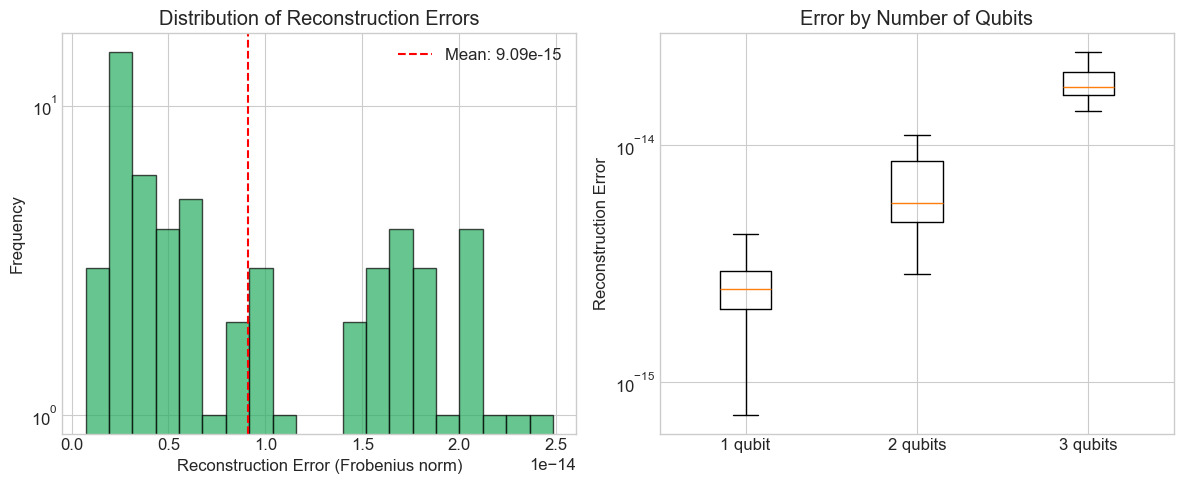

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Histogram of errors
ax1.hist(errors, bins=20, color='#27ae60', edgecolor='black', alpha=0.7)
ax1.set_xlabel('Reconstruction Error (Frobenius norm)')
ax1.set_ylabel('Frequency')
ax1.set_title('Distribution of Reconstruction Errors')
ax1.set_yscale('log')
ax1.axvline(np.mean(errors), color='red', linestyle='--', label=f'Mean: {np.mean(errors):.2e}')
ax1.legend()

# Box plot by qubit count
data_by_qubits = {q: [e for e, d in zip(errors, dims) if d == q] for q in [1, 2, 3]}
ax2.boxplot([data_by_qubits[q] for q in [1, 2, 3]], labels=['1 qubit', '2 qubits', '3 qubits'])
ax2.set_ylabel('Reconstruction Error')
ax2.set_title('Error by Number of Qubits')
ax2.set_yscale('log')

plt.tight_layout()
plt.show()

## 8. Summary Dashboard

All-in-one view for a single decomposition.

Starting recursive KAK-decomposition, alternating AIII/A...
Decomposition complete.

Decomposition Summary:
  num_leaves: 8
  depth: 2
  gate_counts: {'SX': 16, 'Rz': 24, 'X': 0, 'CRY': 2, 'CRZ': 4}


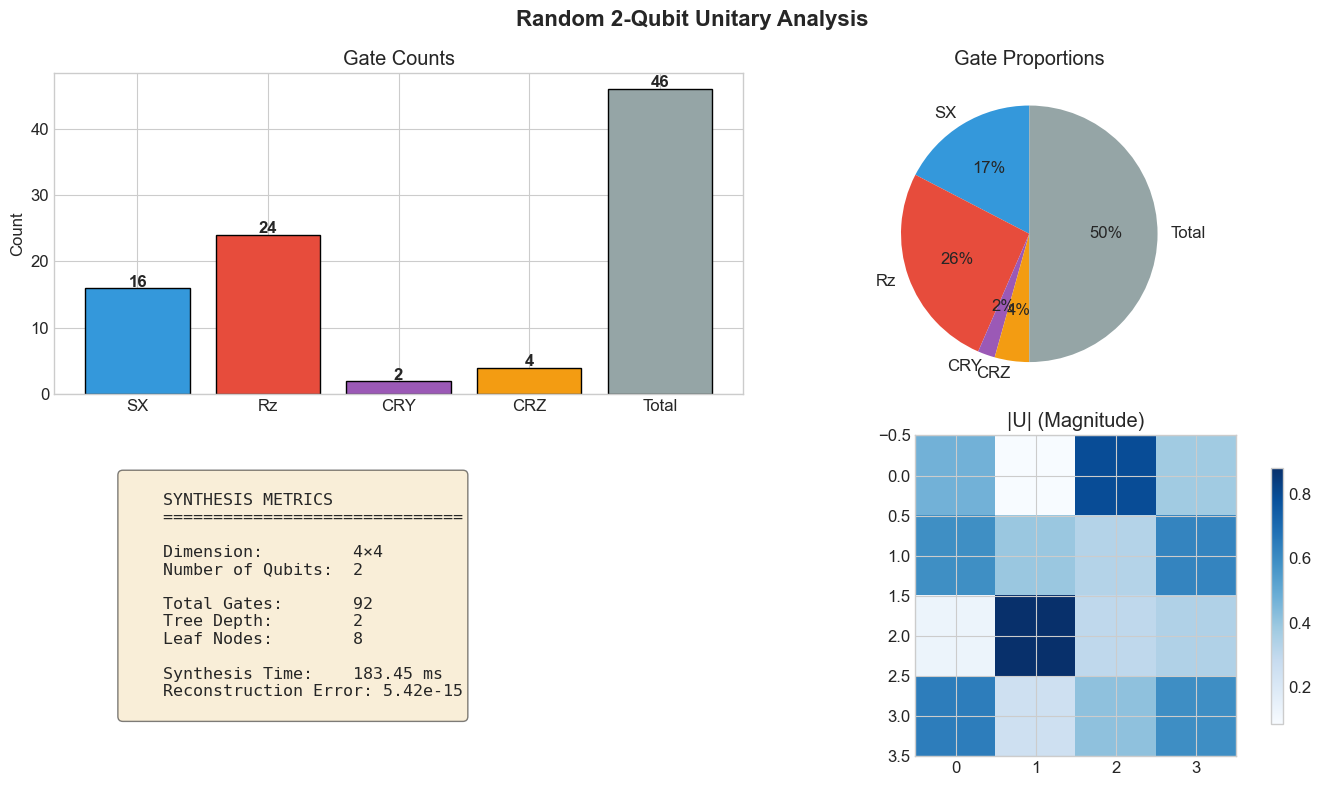

In [15]:
def create_dashboard(U, title="Unitary Synthesis Dashboard"):
    """Create a comprehensive dashboard for a unitary decomposition."""
    synth = UnitarySynthesiser(U)
    
    start = time.time()
    synth.decompose()
    elapsed = time.time() - start
    
    counts = synth.count_gates()
    info = synth.get_info()
    error = compute_error(synth)
    
    fig = plt.figure(figsize=(14, 8))
    fig.suptitle(title, fontsize=16, fontweight='bold')
    
    # Gate counts bar chart
    ax1 = fig.add_subplot(2, 2, 1)
    gates = [k for k, v in counts.items() if v > 0]
    values = [counts[k] for k in gates]
    colors = {'SX': '#3498db', 'Rz': '#e74c3c', 'X': '#2ecc71', 'CRY': '#9b59b6', 'CRZ': '#f39c12'}
    bar_colors = [colors.get(g, '#95a5a6') for g in gates]
    if values:
        ax1.bar(gates, values, color=bar_colors, edgecolor='black')
        for i, (g, v) in enumerate(zip(gates, values)):
            ax1.text(i, v + 0.2, str(v), ha='center', fontweight='bold')
    ax1.set_title('Gate Counts')
    ax1.set_ylabel('Count')
    
    # Pie chart
    ax2 = fig.add_subplot(2, 2, 2)
    if values:
        ax2.pie(values, labels=gates, autopct='%1.0f%%', colors=bar_colors, startangle=90)
    ax2.set_title('Gate Proportions')
    
    # Metrics text
    ax3 = fig.add_subplot(2, 2, 3)
    ax3.axis('off')
    metrics_text = f"""
    SYNTHESIS METRICS
    {'='*30}
        
    Dimension:         {len(U)}×{len(U)}
    Number of Qubits:  {synth.nqubits}
    
    Total Gates:       {sum(counts.values())}
    Tree Depth:        {info['depth']}
    Leaf Nodes:        {info['num_leaves']}
    
    Synthesis Time:    {elapsed*1000:.2f} ms
    Reconstruction Error: {error:.2e}
    """
    ax3.text(0.1, 0.5, metrics_text, fontfamily='monospace', fontsize=12,
             verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # Unitary magnitude heatmap
    ax4 = fig.add_subplot(2, 2, 4)
    im = ax4.imshow(np.abs(U), cmap='Blues')
    ax4.set_title('|U| (Magnitude)')
    plt.colorbar(im, ax=ax4, shrink=0.8)
    
    plt.tight_layout()
    return fig, synth

# Create dashboard for a random 2-qubit unitary
U = unitary_group.rvs(4)
fig, synth = create_dashboard(U, "Random 2-Qubit Unitary Analysis")
plt.show()